In [79]:
import pandas as pd

# Specify the input .xpt file and the output CSV file paths.
input_file = '/Users/alexkuai/Downloads/WHQ_L.xpt'    # Replace with your XPT file path.
output_file = 'WHQ_L.csv'   # Replace with your desired CSV file path.

# Read the SAS XPT file. The 'format' parameter is set to 'xport' to indicate the file type.
df = pd.read_sas(input_file, format='xport')

# Write the DataFrame to a CSV file without including the index.
df.to_csv(output_file, index=False)

print(f"Successfully converted {input_file} to {output_file}.")


Successfully converted /Users/alexkuai/Downloads/WHQ_L.xpt to WHQ_L.csv.


In [2]:
import pandas as pd
nhanes = pd.read_csv("WHQ_L.csv")
nhanes

,SEQN,WHD010,WHD020,WHD050,WHQ070
0,130378.0,71.0,190.0,200.0,1.0
1,130379.0,70.0,220.0,220.0,2.0
2,130380.0,60.0,150.0,165.0,1.0
3,130384.0,68.0,204.0,212.0,1.0
4,130385.0,70.0,240.0,240.0,2.0
...,...,...,...,...,...
8496,142305.0,61.0,137.0,134.0,2.0
8497,142307.0,61.0,206.0,235.0,1.0
8498,142308.0,69.0,174.0,180.0,1.0
8499,142309.0,69.0,200.0,170.0,2.0


In [33]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.linalg import fractional_matrix_power
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- Step 1. Load and Aggregate the Data ---
df = pd.read_csv('weight.csv')
print("Data preview:")
print(df.head())

# Define the response labels
normal_label = "Normal weight (BMI from 18.5 to 24.9)"
grade1_label = "Grade 1 obesity (BMI from 30.0 to 34.9)"
grade2_label = "Grade 2 obesity (BMI from 35.0 to 39.9)"
grade3_label = "Grade 3 obesity (BMI greater than or equal to 40.0)"
overweight_or_obese_label = "Overweight or obese (BMI greater than or equal to 25.0)"

# Pivot using the ESTIMATE column (averaging if needed)
df_pivot = df.pivot_table(index=['YEAR', 'YEAR_NUM'], 
                          columns='PANEL', 
                          values='ESTIMATE', 
                          aggfunc='mean').reset_index()
print("\nPivoted DataFrame (using ESTIMATE):")
print(df_pivot.head())

# --- Step 2. Build the Cross-Sectional Distribution ---
df_pivot['Obesity'] = (df_pivot.get(grade1_label, 0) +
                       df_pivot.get(grade2_label, 0) +
                       df_pivot.get(grade3_label, 0))
df_pivot['Overweight'] = df_pivot.get(overweight_or_obese_label, 0) - df_pivot['Obesity']
df_pivot['Overweight'] = df_pivot['Overweight'].clip(lower=0)
df_pivot['Normal'] = df_pivot.get(normal_label, 0)

df_states = df_pivot[['YEAR', 'YEAR_NUM', 'Normal', 'Overweight', 'Obesity']].copy()
# Normalize so that the three states sum to 1.
df_states[['Normal', 'Overweight', 'Obesity']] = df_states[['Normal', 'Overweight', 'Obesity']].div(
    df_states[['Normal', 'Overweight', 'Obesity']].sum(axis=1), axis=0
)

# --- Incorporate the Insufficient Weight Class ---
min_year = df_states['YEAR_NUM'].min()
max_year = df_states['YEAR_NUM'].max()
df_states['Insufficient'] = 0.023 - (0.023 - 0.016) * (df_states['YEAR_NUM'] - min_year) / (max_year - min_year)

# Re-scale the other three states so they sum to (1 - Insufficient)
df_states['Normal'] = df_states['Normal'] * (1 - df_states['Insufficient'])
df_states['Overweight'] = df_states['Overweight'] * (1 - df_states['Insufficient'])
df_states['Obesity'] = df_states['Obesity'] * (1 - df_states['Insufficient'])
df_states['total'] = df_states['Insufficient'] + df_states['Normal'] + df_states['Overweight'] + df_states['Obesity']
print("\nAggregated and normalized distributions by period (4 states):")
print(df_states[['YEAR', 'YEAR_NUM', 'Insufficient', 'Normal', 'Overweight', 'Obesity', 'total']])

# --- Step 3. Estimate the Yearly Markov Transition Matrix (4x4) ---
states = ['Insufficient', 'Normal', 'Overweight', 'Obesity']
distributions = df_states[states].to_numpy()

# Build lists for consecutive snapshots and effective time differences:
pairs = []
delta_ts = []
for i in range(len(distributions) - 1):
    d_start = distributions[i]
    d_next = distributions[i+1]
    dt = 6 if df_states.iloc[i]['YEAR_NUM'] == 1 else 2
    pairs.append((d_start, d_next))
    delta_ts.append(dt)

# Define the objective function with an extra penalty on the overweight->obesity transition:
def objective(params):
    T = params.reshape((4,4))
    # Basic feasibility: nonnegative and rows sum to 1
    if np.any(T < 0):
        return 1e6
    penalty_basic = np.sum((T.sum(axis=1) - 1)**2) * 1e3
    error = 0
    for (d_start, d_next), dt in zip(pairs, delta_ts):
        T_dt = fractional_matrix_power(T, dt)
        predicted = d_start.dot(T_dt)
        error += np.sum((predicted - d_next)**2)
    # Additional regularization:
    # Increase the overweight->obesity rate: enforce T[2,3] to be at least a higher threshold.
    threshold = 0.06  # increased from 0.03 to 0.06
    penalty_overweight_to_obesity = 1e3 * max(0, threshold - T[2, 3])**2
    return error + penalty_basic + penalty_overweight_to_obesity

# Initial guess for T: nearly diagonal.
T0 = np.full((4,4), 0.1/3)
np.fill_diagonal(T0, 0.9)
T0_flat = T0.flatten()

def constraint_row_sum(params):
    T = params.reshape((4,4))
    return np.array([np.sum(T[i, :]) - 1 for i in range(4)])
constraints = {'type': 'eq', 'fun': constraint_row_sum}
bounds = [(0, 1) for _ in range(16)]

result = minimize(objective, T0_flat, bounds=bounds, constraints=constraints, method='SLSQP')
T_opt = result.x.reshape((4,4))

print("\nOptimized yearly Markov Transition Matrix (4x4):")
for i, state in enumerate(states):
    row = ", ".join([f"{x:.4f}" for x in T_opt[i]])
    print(f"{state}: {row}")


Data preview:
                                           INDICATOR  \
0  Normal weight, overweight, and obesity among a...   
1  Normal weight, overweight, and obesity among a...   
2  Normal weight, overweight, and obesity among a...   
3  Normal weight, overweight, and obesity among a...   
4  Normal weight, overweight, and obesity among a...   

                                   PANEL  PANEL_NUM  \
0  Normal weight (BMI from 18.5 to 24.9)          1   
1  Normal weight (BMI from 18.5 to 24.9)          1   
2  Normal weight (BMI from 18.5 to 24.9)          1   
3  Normal weight (BMI from 18.5 to 24.9)          1   
4  Normal weight (BMI from 18.5 to 24.9)          1   

                                  UNIT  UNIT_NUM STUB_NAME  STUB_NAME_NUM  \
0  Percent of population, age-adjusted         1     Total              1   
1  Percent of population, age-adjusted         1     Total              1   
2  Percent of population, age-adjusted         1     Total              1   
3  Percent

In [15]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.linalg import expm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- Step 1. Load and Aggregate the Data ---
df = pd.read_csv('weight.csv')
print("Data preview:")
print(df.head())

# Define the response labels
normal_label = "Normal weight (BMI from 18.5 to 24.9)"
grade1_label = "Grade 1 obesity (BMI from 30.0 to 34.9)"
grade2_label = "Grade 2 obesity (BMI from 35.0 to 39.9)"
grade3_label = "Grade 3 obesity (BMI greater than or equal to 40.0)"
overweight_or_obese_label = "Overweight or obese (BMI greater than or equal to 25.0)"

# Pivot using the ESTIMATE column (averaging if needed)
df_pivot = df.pivot_table(index=['YEAR', 'YEAR_NUM'], 
                          columns='PANEL', 
                          values='ESTIMATE', 
                          aggfunc='mean').reset_index()
print("\nPivoted DataFrame (using ESTIMATE):")
print(df_pivot.head())

# --- Step 2. Build the Cross-Sectional Distribution ---
df_pivot['Obesity'] = (df_pivot.get(grade1_label, 0) +
                       df_pivot.get(grade2_label, 0) +
                       df_pivot.get(grade3_label, 0))
df_pivot['Overweight'] = df_pivot.get(overweight_or_obese_label, 0) - df_pivot['Obesity']
df_pivot['Overweight'] = df_pivot['Overweight'].clip(lower=0)
df_pivot['Normal'] = df_pivot.get(normal_label, 0)

df_states = df_pivot[['YEAR', 'YEAR_NUM', 'Normal', 'Overweight', 'Obesity']].copy()
# Normalize so that the three states sum to 1.
df_states[['Normal', 'Overweight', 'Obesity']] = df_states[['Normal', 'Overweight', 'Obesity']].div(
    df_states[['Normal', 'Overweight', 'Obesity']].sum(axis=1), axis=0
)

# --- Incorporate the Insufficient Weight Class ---
min_year = df_states['YEAR_NUM'].min()
max_year = df_states['YEAR_NUM'].max()
df_states['Insufficient'] = 0.023 - (0.023 - 0.016) * (df_states['YEAR_NUM'] - min_year) / (max_year - min_year)

# Re-scale the other three states so they sum to (1 - Insufficient)
df_states['Normal'] = df_states['Normal'] * (1 - df_states['Insufficient'])
df_states['Overweight'] = df_states['Overweight'] * (1 - df_states['Insufficient'])
df_states['Obesity'] = df_states['Obesity'] * (1 - df_states['Insufficient'])
df_states['total'] = df_states['Insufficient'] + df_states['Normal'] + df_states['Overweight'] + df_states['Obesity']
print("\nAggregated and normalized distributions by period (4 states):")
print(df_states[['YEAR', 'YEAR_NUM', 'Insufficient', 'Normal', 'Overweight', 'Obesity', 'total']])

# --- Step 3. Prepare Data for Estimating the Generator ---
states = ['Insufficient', 'Normal', 'Overweight', 'Obesity']
distributions = df_states[states].to_numpy()

# Build pairs of consecutive snapshots along with the effective time difference (dt)
pairs = []
delta_ts = []
for i in range(len(distributions) - 1):
    d_start = distributions[i]
    d_next = distributions[i + 1]
    # Use dt = 6 if it's the first period (YEAR_NUM==1) else dt = 2
    dt = 6 if df_states.iloc[i]['YEAR_NUM'] == 1 else 2
    pairs.append((d_start, d_next))
    delta_ts.append(dt)

# --- Step 4. Estimate the Continuous-Time Generator Matrix Q ---
# We will parameterize Q as a 4x4 matrix with 12 free parameters.
# For each row i, for j != i, let Q[i,j] = free_param.
# Then set Q[i,i] = -sum_{j != i} Q[i,j] so that each row sums to zero.

def build_generator(free_params):
    """
    Convert 12 free parameters into a 4x4 generator matrix Q.
    The free_params are ordered row-wise for the off-diagonals.
    """
    Q = np.zeros((4, 4))
    index = 0
    for i in range(4):
        for j in range(4):
            if i == j:
                continue
            Q[i, j] = free_params[index]
            index += 1
        Q[i, i] = -np.sum(Q[i, :])
    return Q

def generator_objective(free_params, pairs, delta_ts):
    """
    Objective function that computes the sum of squared errors between 
    observed state distributions and those predicted by evolving the system
    using the generator matrix Q over time intervals delta_ts.
    """
    Q = build_generator(free_params)
    error = 0.0
    for (d_start, d_next), dt in zip(pairs, delta_ts):
        # Compute the transition matrix over time dt via the matrix exponential:
        T_dt = expm(dt * Q)
        predicted = d_start.dot(T_dt)
        error += np.sum((predicted - d_next) ** 2)
    return error

# Initial guess for the 12 free parameters (all nonnegative rates)
initial_guess = np.full(12, 0.01)

# Bounds: all free parameters must be nonnegative
bounds = [(0, None) for _ in range(12)]

result = minimize(generator_objective, initial_guess, args=(pairs, delta_ts),
                  bounds=bounds, method='L-BFGS-B')

# Reconstruct the optimized generator matrix Q and the yearly transition matrix T
Q_opt = build_generator(result.x)
T_yearly = expm(1 * Q_opt)  # For a yearly transition, dt = 1

print("\nOptimized Generator Matrix (Q):")
print(Q_opt)

print("\nEstimated Yearly Transition Matrix (T = expm(Q)):")
for i, state in enumerate(states):
    row = ", ".join([f"{x:.4f}" for x in T_yearly[i]])
    print(f"{state}: {row}")


Data preview:
                                           INDICATOR  \
0  Normal weight, overweight, and obesity among a...   
1  Normal weight, overweight, and obesity among a...   
2  Normal weight, overweight, and obesity among a...   
3  Normal weight, overweight, and obesity among a...   
4  Normal weight, overweight, and obesity among a...   

                                   PANEL  PANEL_NUM  \
0  Normal weight (BMI from 18.5 to 24.9)          1   
1  Normal weight (BMI from 18.5 to 24.9)          1   
2  Normal weight (BMI from 18.5 to 24.9)          1   
3  Normal weight (BMI from 18.5 to 24.9)          1   
4  Normal weight (BMI from 18.5 to 24.9)          1   

                                  UNIT  UNIT_NUM STUB_NAME  STUB_NAME_NUM  \
0  Percent of population, age-adjusted         1     Total              1   
1  Percent of population, age-adjusted         1     Total              1   
2  Percent of population, age-adjusted         1     Total              1   
3  Percent

In [155]:
np.unique(df['PANEL'])

array(['Grade 1 obesity (BMI from 30.0 to 34.9)',
       'Grade 2 obesity (BMI from 35.0 to 39.9)',
       'Grade 3 obesity (BMI greater than or equal to 40.0)',
       'Normal weight (BMI from 18.5 to 24.9)',
       'Obesity (BMI greater than or equal to 30.0)',
       'Overweight or obese (BMI greater than or equal to 25.0)'],
      dtype=object)

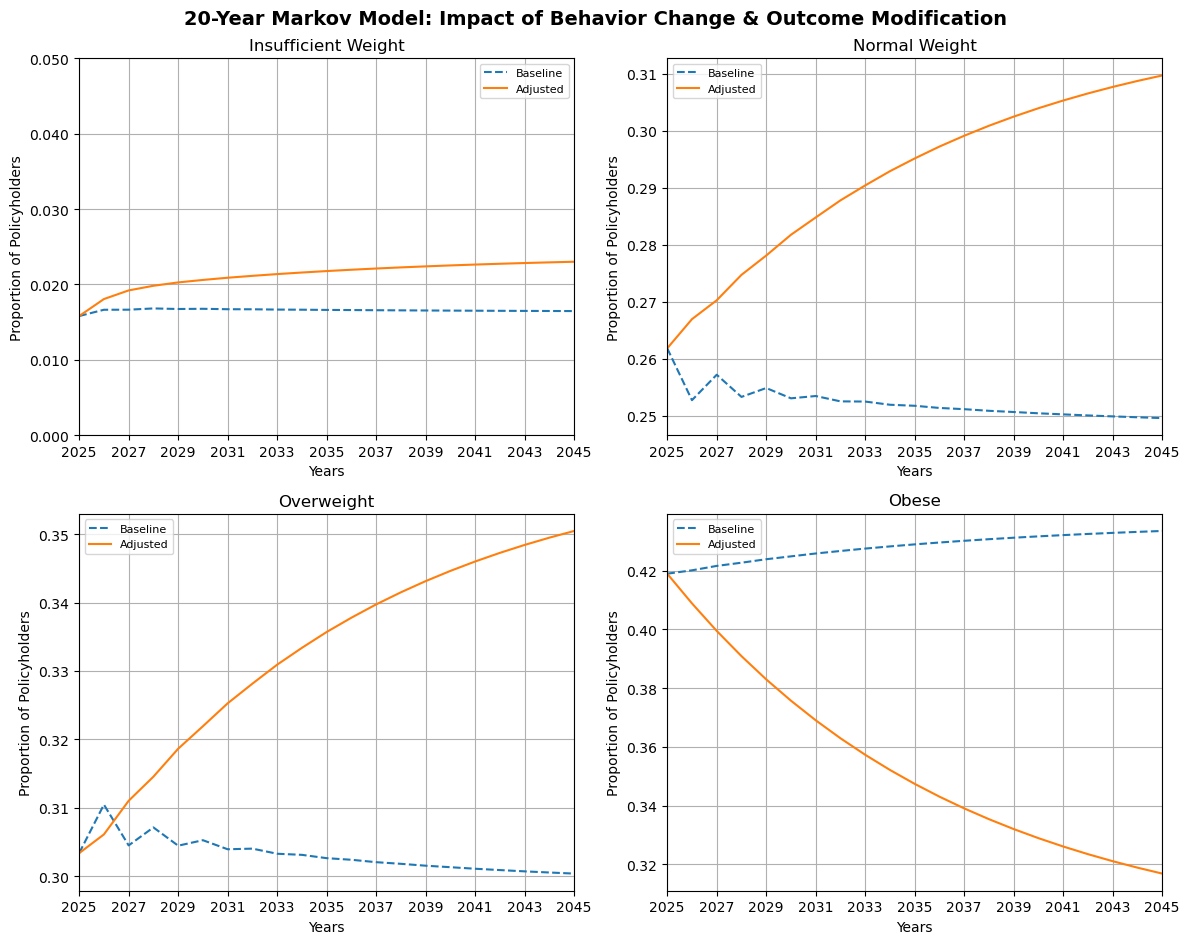

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# Define states:
# 0: Insufficient Weight, 1: Normal Weight, 2: Overweight, 3: Obese

# Baseline transition matrix (each row sums to 1)
P = T_opt.copy()

# Compute mean modifier values from the given CI bounds:
mean_NW_to_OW = 0.15    # ~0.13495  reduction of probability using the behavior changes
mean_OW_to_NW = 0.13495      # ~0.13495 reduction of probability using the modifying outcomes
mean_OW_to_OB = 0.22025       # ~0.22025 reduction of probability using the modifying outcomes
mean_OB_to_OW = 0.3614       # ~0.3614 reduction of probability using the modifying outcomes

# Create a modifiers matrix using the mean values
modifiers_mean = np.ones_like(P)
modifiers_mean[1, 2] = 1 - mean_NW_to_OW    # Normal Weight -> Overweight multiplier
modifiers_mean[2, 1] = 1 + mean_OW_to_NW      # Overweight -> Normal Weight multiplier
modifiers_mean[2, 3] = 1 - mean_OW_to_OB      # Overweight -> Obese multiplier
modifiers_mean[3, 2] = 1 + mean_OB_to_OW      # Obese -> Overweight multiplier

# Apply the mean modifiers to the baseline transition matrix and normalize rows
P_mean = P * modifiers_mean
P_mean = P_mean / P_mean.sum(axis=1, keepdims=True)

# Define the updated initial population with 1.6% Insufficient Weight
init_dist = np.array([
    0.016,  # Insufficient Weight (1.6% of population)
    0.265,  # Normal Weight (26.5% of population)
    0.307,  # Overweight (30.7% of population)
    0.424   # Obese (42.4% of population)
])
init_dist = init_dist / init_dist.sum()  # Normalize

# Simulation parameters
T = 20  # Simulate for 10 years

# Storage for population distributions (Baseline and Mean Intervention)
n_states = len(init_dist)
dist_baseline = np.zeros((T+1, n_states))
dist_mean = np.zeros((T+1, n_states))

dist_baseline[0] = init_dist
dist_mean[0] = init_dist

# Simulate the Markov process over T years
for t in range(1, T+1):
    dist_baseline[t] = dist_baseline[t-1] @ P
    dist_mean[t] = dist_mean[t-1] @ P_mean

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# Define simulation horizon
T = 20  # 20-year simulation
years = np.arange(T+1)  # x-values: 0, 1, ..., 20

# Set new tick positions (corresponding to every 2 years) and labels starting from 2025.
new_tick_positions = np.arange(0, T+1, 2)  # positions in the simulation (e.g., 0,2,...,20)
new_tick_labels = np.arange(2025, 2025 + T + 1, 2)  # labels: 2025,2027,...,2045

# Plot the results in 4 separate subplots (one for each state)
state_labels = ['Insufficient Weight', 'Normal Weight', 'Overweight', 'Obese']
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for i, ax in enumerate(axs):
    ax.plot(years, dist_baseline[:, i], '--', label='Baseline')
    ax.plot(years, dist_mean[:, i], '-', label='Adjusted')
    ax.set_title(state_labels[i])
    ax.set_xlabel("Years")
    ax.set_ylabel("Proportion of Policyholders")
    ax.legend(fontsize=8)
    ax.grid(True)
    # For the Insufficient Weight state, use 3 decimal places and a broader y-axis range.
    if state_labels[i] == "Insufficient Weight":
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
        ax.set_ylim(0, 0.050)  # adjust as needed
    else:
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    # Set the x-ticks to be every 2 simulation years and update their labels to real years starting at 2025.
    ax.set_xticks(new_tick_positions)
    ax.set_xticklabels(new_tick_labels)
    ax.set_xlim(0, T)

fig.suptitle("20-Year Markov Model: Impact of Behavior Change & Outcome Modification", 
             fontsize=14, y=0.94, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("markov.png")
plt.show()




In [36]:
# Print the class distributions for each year
print("Year | Baseline Distribution                   | Adjusted Distribution")
print("-----|-----------------------------------------|------------------------")
for t in range(T + 1):
    baseline_str = ", ".join(f"{v:.4f}" for v in dist_baseline[t])
    adjusted_str = ", ".join(f"{v:.4f}" for v in dist_mean[t])
    print(f"{2025 + t} | {baseline_str} | {adjusted_str}")


Year | Baseline Distribution                   | Adjusted Distribution
-----|-----------------------------------------|------------------------
2025 | 0.0158, 0.2619, 0.3034, 0.4190 | 0.0158, 0.2619, 0.3034, 0.4190
2026 | 0.0166, 0.2528, 0.3105, 0.4201 | 0.0181, 0.2670, 0.3061, 0.4089
2027 | 0.0167, 0.2572, 0.3045, 0.4216 | 0.0192, 0.2703, 0.3110, 0.3995
2028 | 0.0168, 0.2533, 0.3071, 0.4227 | 0.0198, 0.2747, 0.3145, 0.3909
2029 | 0.0167, 0.2549, 0.3045, 0.4239 | 0.0203, 0.2781, 0.3186, 0.3830
2030 | 0.0168, 0.2531, 0.3053, 0.4249 | 0.0206, 0.2818, 0.3219, 0.3757
2031 | 0.0167, 0.2535, 0.3039, 0.4259 | 0.0209, 0.2848, 0.3253, 0.3691
2032 | 0.0167, 0.2526, 0.3040, 0.4267 | 0.0211, 0.2878, 0.3281, 0.3629
2033 | 0.0167, 0.2525, 0.3033, 0.4275 | 0.0214, 0.2904, 0.3309, 0.3573
2034 | 0.0167, 0.2520, 0.3031, 0.4283 | 0.0216, 0.2929, 0.3334, 0.3521
2035 | 0.0166, 0.2518, 0.3026, 0.4290 | 0.0218, 0.2951, 0.3357, 0.3474
2036 | 0.0166, 0.2514, 0.3024, 0.4296 | 0.0220, 0.2972, 0.3378, 0.3430
2037

In [41]:
# Define constants
num_policyholders = 100_000

# Medical cost per individual in each risk class (only overweight and obese)
cost_overweight = 600
cost_obese = 1816
coverage_ratio = 0.70  # Insurer covers 70% of costs

# Premium tiers and distribution
premium_flat = 500
premium_baseline = 475
premium_engaged = 450
premium_optimal = 425
tier_dist = [0.50, 0.35, 0.15]  # Proportion of people in each tier

# Pre-compute total discounted revenue per year
revenue_flat = num_policyholders * premium_flat
revenue_tiered = (tier_dist[0] * num_policyholders * premium_baseline +
                  tier_dist[1] * num_policyholders * premium_engaged +
                  tier_dist[2] * num_policyholders * premium_optimal)
revenue_loss = revenue_flat - revenue_tiered

# Track results over time
yearly_baseline_costs = []
yearly_adjusted_costs = []
yearly_savings = []
yearly_net_savings = []

for t in range(T + 1):
    # Extract proportions
    overweight_base = dist_baseline[t][2]
    obese_base = dist_baseline[t][3]
    overweight_adj = dist_mean[t][2]
    obese_adj = dist_mean[t][3]

    # Convert to number of people
    overweight_base_count = overweight_base * num_policyholders
    obese_base_count = obese_base * num_policyholders
    overweight_adj_count = overweight_adj * num_policyholders
    obese_adj_count = obese_adj * num_policyholders

    # Compute yearly medical costs
    cost_base = coverage_ratio * (obese_base_count * cost_obese + overweight_base_count * cost_overweight)
    cost_adj = coverage_ratio * (obese_adj_count * cost_obese + overweight_adj_count * cost_overweight)

    # Calculate savings and net savings
    medical_savings = cost_base - cost_adj
    net_saving = medical_savings - revenue_loss
    print(cost_base, cost_adj, revenue_loss)
    print(net_saving)
    # Store results
    yearly_baseline_costs.append(cost_base)
    yearly_adjusted_costs.append(cost_adj)
    yearly_savings.append(medical_savings)
    yearly_net_savings.append(net_saving)


66000869.56521738 66000869.56521738 4125000.0
-4125000.0
66445566.0574959 64831258.711612105 4125000.0
-2510692.654116206
66385781.78700674 63846425.75808179 4125000.0
-1585643.971075043
66634561.34504471 62901998.2130693 4125000.0
-392436.86802458763
66673220.36817995 62067298.37825477 4125000.0
480921.9899251759
66831136.249922 61282646.665264 4125000.0
1423489.584657997
66899671.601128444 60574937.24689747 4125000.0
2199734.3542309776
67012222.99596146 59917353.88432685 4125000.0
2969869.1116346046
67084946.71350827 59318736.09439991 4125000.0
3641210.619108364
67171984.00153308 58765852.74022012 4125000.0
4281131.261312954
67239767.09735109 58260324.39151971 4125000.0
4854442.705831379
67310392.06933554 57794816.878480464 4125000.0
5390575.190855071
67370536.52155429 57368271.57867457 4125000.0
5877264.9428797215
67429325.33092152 56976074.37094988 4125000.0
6328250.9599716365
67481572.93122354 56616329.48634513 4125000.0
6740243.444878414
67531138.45570521 56285793.24314846 412500

In [38]:
np.sum(yearly_net_savings)

82992139.01584354

In [39]:
yearly_net_savings[19]

8354201.090658531

In [13]:
modifiers_mean

array([[1.     , 1.     , 1.     , 1.     ],
       [1.     , 1.     , 0.85   , 1.     ],
       [1.     , 1.13495, 1.     , 0.77975],
       [1.     , 1.     , 1.3614 , 1.     ]])

In [20]:
P_mean 

array([[9.54824157e-01, 1.25435466e-02, 1.53346576e-02, 1.72976386e-02],
       [1.89096176e-03, 9.08349610e-01, 3.62713983e-02, 5.34880303e-02],
       [4.07585675e-04, 2.80647261e-02, 9.51480912e-01, 2.00467762e-02],
       [1.52483768e-04, 4.27084426e-02, 1.46620281e-02, 9.42477045e-01]])

In [10]:
P

array([[4.11848909e-01, 2.68898852e-01, 3.19252240e-01, 4.05551122e-16],
       [3.73902641e-02, 1.04159013e-01, 8.54660878e-01, 3.78984543e-03],
       [7.69985420e-04, 7.29317379e-01, 2.08941992e-01, 6.09706430e-02],
       [2.59399268e-04, 4.00835615e-16, 4.35039341e-02, 9.56236667e-01]])

In [132]:
0.31688725*100000

31688.725000000002

In [131]:
dist_baseline

array([[0.01581028, 0.26185771, 0.30335968, 0.41897233],
       [0.01664464, 0.2527717 , 0.31045853, 0.42012514],
       [0.01665431, 0.25722697, 0.30449284, 0.42162589],
       [0.01682067, 0.25334275, 0.30712248, 0.42271411],
       [0.01674626, 0.25490075, 0.30445268, 0.42390031],
       [0.01677212, 0.25309589, 0.30525426, 0.42487773],
       [0.01671615, 0.25349946, 0.30392998, 0.42585441],
       [0.01670743, 0.25256062, 0.30402282, 0.42670913],
       [0.01666903, 0.2525282 , 0.30327423, 0.42752855],
       [0.01665163, 0.25196853, 0.30311349, 0.42826634],
       [0.01662361, 0.25178833, 0.30262813, 0.42895993],
       [0.01660514, 0.25140805, 0.30239393, 0.42959288],
       [0.0165833 , 0.25119267, 0.30204162, 0.43018241],
       [0.01656613, 0.25090741, 0.30180261, 0.43072385],
       [0.01654835, 0.25069877, 0.30152694, 0.43122594],
       [0.01653314, 0.25047121, 0.30130719, 0.43168846],
       [0.01651832, 0.25028315, 0.30108206, 0.43211647],
       [0.01650513, 0.25009538,